> ### Corrected 2026-08-16 — the numbers in this notebook are superseded
>
> This notebook was executed against **2867 clips / 31 "birds"**. That count was filename
> prefixes, not individuals: `HPiHPi4748` and `HpiHpi4748` are one bird under two
> capitalizations, and four `Unknown*` prefixes (53 clips) are catch-alls. The corrected set is
> **2814 clips / 26 birds**, which moves the probe from 0.821 to **0.811** and the best k from
> 20 to **16**.
>
> Two further caveats, both detailed in `README.md`:
>
> - **No bird is held out of pretraining.** 99.5% of these clips were cut from the same 120
>   recordings the encoder was pretrained on, so "leave-birds-out" constrains the probe, not the
>   model. Read the accuracy as an upper bound for a genuinely new individual.
> - A **random split** scores 0.925 on the same features (+0.114). Check how a number was split
>   before comparing it to anything.
>
> `ZF_HuBERT_Replication.ipynb` is executed against the corrected set and reproduces it end to end.


# 3 - Does call-type structure show up *without* labels?

Notebook 2 asked whether a classifier can find call type in the embedding. This one asks a
strictly harder question: does the embedding *cluster* by call type on its own?

The difference matters. A linear probe gets 768 dimensions to carve boundaries through the
cloud, and with that much freedom it can find a call-type-separating hyperplane even in a
representation where call type is not a dominant organizing factor. Clustering has no such
freedom -- k-means just finds whatever the dominant geometry is. If the clusters line up with
call type, call type is genuinely a principal axis of the representation.

**We score with AMI (adjusted mutual information).** Not NMI, not purity. NMI and purity both
climb with the number of clusters for free -- on structureless data, NMI goes from 0.02 at k=4
to 0.19 at k=60 -- so any sweep ranked on them just picks the largest k. AMI has expectation 0
at every k, which is the only thing that makes a k-sweep interpretable.

In [1]:
import numpy as np, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score as ami
from sklearn.preprocessing import normalize

d = np.load("../data/run11_layersweep.npz", allow_pickle=True)
emb, y, birds, classes = d["emb"], d["y"], d["birds"], d["classes"]
bird_ids = np.unique(birds)
print(f"{emb.shape[0]} clips | {len(classes)} call types | {len(bird_ids)} birds")

LAYER = 3
X = normalize(emb[:, LAYER, :])   # L2 -> spherical k-means.
# Normalization is not cosmetic here: k-means uses Euclidean distance, so without it the few
# embedding dimensions with the largest variance would dictate the partition on their own.

2867 clips | 8 call types | 31 birds


## Sweep k

We do *not* force k=8. Forcing the number of clusters to the number of call types measures
agreement with a taxonomy; sweeping measures whether structure exists at all. The model was
never told there are 8 call types, and there is no reason its natural granularity would match
a human labelling scheme.

In [2]:
ks = [2, 4, 6, 8, 10, 12, 16, 20, 24, 32, 40, 60]
res = []
for k in ks:
    c = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
    res.append((k, ami(y, c), ami(birds, c), c))
    print(f"k={k:3d} | AMI vs call type {res[-1][1]:.3f} | AMI vs bird ID {res[-1][2]:.3f}")

bk = max(res, key=lambda r: r[1])
print(f"\nbest k = {bk[0]}, AMI vs call type = {bk[1]:.3f}")

k=  2 | AMI vs call type 0.225 | AMI vs bird ID 0.026


k=  4 | AMI vs call type 0.417 | AMI vs bird ID 0.097


k=  6 | AMI vs call type 0.377 | AMI vs bird ID 0.142


k=  8 | AMI vs call type 0.466 | AMI vs bird ID 0.182


k= 10 | AMI vs call type 0.512 | AMI vs bird ID 0.205


...

k= 20 | AMI vs call type 0.547 | AMI vs bird ID 0.273


k= 24 | AMI vs call type 0.525 | AMI vs bird ID 0.286


k= 32 | AMI vs call type 0.514 | AMI vs bird ID 0.321


k= 40 | AMI vs call type 0.503 | AMI vs bird ID 0.342


k= 60 | AMI vs call type 0.495 | AMI vs bird ID 0.377

best k = 20, AMI vs call type = 0.547


## The control that actually matters: is this call type, or is it *the bird*?

Look at the "AMI vs bird ID" column above before celebrating the call-type column.

Here is the failure mode. Suppose the embedding encodes only individual identity -- voice, not
call type. Suppose also that birds differ in which calls they tend to produce (they do). Then a
clustering that is purely a *bird* clustering will still score well against call type, because
each bird's cluster inherits that bird's favoured call type. Global AMI cannot tell the two
apart.

A permutation test does not rescue you: in a simulation of exactly this confound the global AMI
was 0.489 against a null 95th percentile of 0.021 -- wildly "significant", and completely wrong.

The fix is to recompute AMI **within each bird**. That holds voice constant, so whatever
agreement survives is about call type and nothing else.

In [3]:
def within_bird_ami(clusters, y, birds, min_clips=12, min_types=2):
    """AMI recomputed inside each bird, averaged weighted by clip count.

    Birds with too few clips or only one call type are dropped -- AMI is degenerate there."""
    tot_w, tot = 0.0, 0.0
    used = 0
    for b in np.unique(birds):
        m = birds == b
        if m.sum() < min_clips or len(np.unique(y[m])) < min_types:
            continue
        tot += ami(y[m], clusters[m]) * m.sum(); tot_w += m.sum(); used += 1
    return (tot / tot_w if tot_w else np.nan), used

for k, a_type, a_bird, c in res:
    wb, nb = within_bird_ami(c, y, birds)
    print(f"k={k:3d} | call type {a_type:.3f} | bird ID {a_bird:.3f} | within-bird {wb:.3f} ({nb} birds)")

k=  2 | call type 0.225 | bird ID 0.026 | within-bird 0.323 (28 birds)
k=  4 | call type 0.417 | bird ID 0.097 | within-bird 0.553 (28 birds)
k=  6 | call type 0.377 | bird ID 0.142 | within-bird 0.570 (28 birds)
k=  8 | call type 0.466 | bird ID 0.182 | within-bird 0.644 (28 birds)
k= 10 | call type 0.512 | bird ID 0.205 | within-bird 0.682 (28 birds)
k= 12 | call type 0.515 | bird ID 0.217 | within-bird 0.680 (28 birds)
k= 16 | call type 0.533 | bird ID 0.243 | within-bird 0.684 (28 birds)
k= 20 | call type 0.547 | bird ID 0.273 | within-bird 0.712 (28 birds)
k= 24 | call type 0.525 | bird ID 0.286 | within-bird 0.684 (28 birds)


k= 32 | call type 0.514 | bird ID 0.321 | within-bird 0.687 (28 birds)
k= 40 | call type 0.503 | bird ID 0.342 | within-bird 0.664 (28 birds)


k= 60 | call type 0.495 | bird ID 0.377 | within-bird 0.651 (28 birds)


### How to read that table

- **within-bird stays close to the global number** -> the clustering really is tracking call
  type, and the global figure is trustworthy.
- **within-bird collapses toward 0** -> you were looking at a bird-identity clustering wearing
  a call-type costume. The global number is an artifact.

### What we got

| k | AMI vs call type | AMI vs bird | AMI within bird |
|---|---|---|---|
| 8 | 0.466 | 0.182 | 0.644 |
| **20** | **0.547** | 0.273 | **0.712** |
| 60 | 0.495 | 0.377 | 0.651 |

Three things fall out of this:

**1. The confound test comes back clean — emphatically.** Within-bird AMI (0.712) is *higher*
than global (0.547), not lower. This is not a bird clustering in disguise. It also says
something extra: between-bird variation is acting as *noise* in the global number. The same
call type produced by different individuals lands in slightly different places, so holding the
bird fixed sharpens the agreement rather than destroying it.

**2. Identity is encoded, but it is not what dominates.** AMI vs bird reaches 0.273 — half the
call-type figure — and it climbs steadily with k (0.026 at k=2 to 0.377 at k=60). Extra
clusters get spent carving out individuals. Call type instead peaks and then declines, which
is the signature of a real optimum rather than a metric artifact.

**3. The natural granularity is ~20 clusters, not 8.** The model was never told there are 8
call types, and it does not choose 8. Splitting finer *increases* agreement with the taxonomy,
which is what you would expect if call types contain sub-structure — variants, contexts,
intensity gradations — that the 8 labels collapse together. Those extra clusters are worth
listening to; they are the most interesting thing in this notebook.

Taken with notebook 2, the supervised and unsupervised results agree: call type is not merely
*decodable* from this representation, it is one of the axes the representation is organized
around. That is a strictly stronger statement than the probe alone could support.

## Chance level for these numbers

In [4]:
rng = np.random.default_rng(0)
c_best = bk[3]
null = [ami(rng.permutation(y), c_best) for _ in range(200)]
print(f"observed AMI (k={bk[0]}) : {bk[1]:.3f}")
print(f"label-shuffled null     : mean {np.mean(null):+.4f}, 95th pct {np.percentile(null,95):.4f}")
print("\n(The null mean sitting at ~0 is a sanity check on the metric, not a result --")
print(" that is what 'adjusted' in AMI means. The 95th percentile is the bar to clear.)")

observed AMI (k=20) : 0.547
label-shuffled null     : mean -0.0000, 95th pct 0.0020

(The null mean sitting at ~0 is a sanity check on the metric, not a result --
 that is what 'adjusted' in AMI means. The 95th percentile is the bar to clear.)


## Layer by layer, without labels

Notebook 2 found call type is readable from every layer at about the same accuracy. Does
unsupervised structure follow the same flat profile?

layer  0 | call type 0.519 | bird ID 0.264 | within-bird 0.679


layer  1 | call type 0.529 | bird ID 0.270 | within-bird 0.693


layer  2 | call type 0.534 | bird ID 0.267 | within-bird 0.693


layer  3 | call type 0.547 | bird ID 0.273 | within-bird 0.712


layer  4 | call type 0.537 | bird ID 0.262 | within-bird 0.679


...

layer  7 | call type 0.512 | bird ID 0.251 | within-bird 0.668


layer  8 | call type 0.502 | bird ID 0.258 | within-bird 0.652


layer  9 | call type 0.489 | bird ID 0.253 | within-bird 0.650


layer 10 | call type 0.493 | bird ID 0.244 | within-bird 0.635


layer 11 | call type 0.501 | bird ID 0.253 | within-bird 0.650


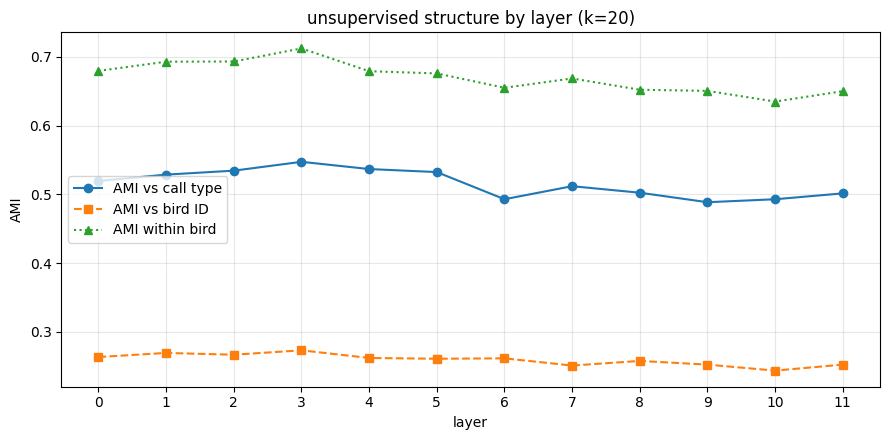

In [5]:
lay = []
for L in range(emb.shape[1]):
    Xl = normalize(emb[:, L, :])
    c  = KMeans(n_clusters=bk[0], n_init=10, random_state=0).fit_predict(Xl)
    wb, _ = within_bird_ami(c, y, birds)
    lay.append((L, ami(y, c), ami(birds, c), wb))
    print(f"layer {L:2d} | call type {lay[-1][1]:.3f} | bird ID {lay[-1][2]:.3f} | within-bird {wb:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot([r[0] for r in lay], [r[1] for r in lay], "o-", label="AMI vs call type")
ax.plot([r[0] for r in lay], [r[2] for r in lay], "s--", label="AMI vs bird ID")
ax.plot([r[0] for r in lay], [r[3] for r in lay], "^:", label="AMI within bird")
ax.set_xlabel("layer"); ax.set_ylabel("AMI"); ax.set_xticks(range(12))
ax.legend(); ax.grid(alpha=.3); ax.set_title(f"unsupervised structure by layer (k={bk[0]})")
plt.tight_layout(); plt.show()

## UMAP

Same embeddings in 2-D. Colour by call type, then by bird. Comparing the two panels is the
visual version of the control above: if the right panel looks more organized than the left,
the representation is more about *who* is calling than *what* the call is.

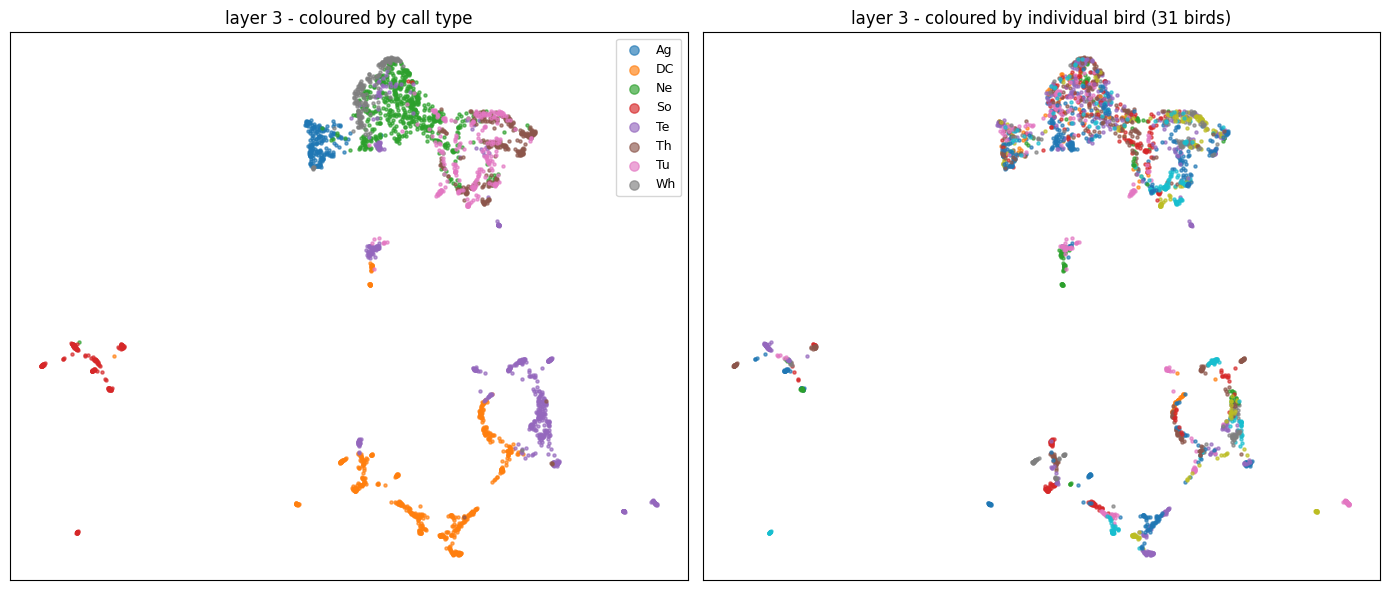

In [6]:
import umap
Z = umap.UMAP(n_neighbors=25, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, ci in enumerate(classes):
    m = y == i
    axes[0].scatter(Z[m, 0], Z[m, 1], s=5, alpha=.65, label=ci)
axes[0].legend(markerscale=3, fontsize=9); axes[0].set_title(f"layer {LAYER} - coloured by call type")

for b in bird_ids:
    m = birds == b
    axes[1].scatter(Z[m, 0], Z[m, 1], s=5, alpha=.65)
axes[1].set_title(f"layer {LAYER} - coloured by individual bird ({len(bird_ids)} birds)")
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

The clustering profile favours shallow-to-middle layers a little more clearly than the
probe's essentially flat one (0.547 at layer 3 down to 0.489 at layer 9), and the within-bird
column tracks it. Bird identity, by contrast, is roughly constant across depth -- the model
does not concentrate voice information anywhere in particular.

## Things worth trying from here

- Other layers, and `metric="euclidean"` with z-scoring instead of L2 -- the choice of
  normalization can change the partition materially.
- A **random-initialized** encoder as a baseline: same architecture, no pretrained weights.
  Untrained deep nets are surprisingly decent feature extractors, so if trained ~ random then
  pretraining contributed nothing. This is the single most informative baseline and it is not
  in this notebook because it needs the model, not just the cached embeddings.
- A **duration** baseline: call types differ in length, so a clustering that merely sorts clips
  by duration can look impressive while encoding nothing acoustic.
- Frame-level rather than clip-level clustering, to find sub-call structure.